# Model Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/model_evaluation.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [The Bias-Variance Tradeoff](#2-the-bias-variance-tradeoff)
3. [Classification Metrics](#3-classification-metrics)
   - 3.1 Confusion Matrix
   - 3.2 Accuracy, Precision, Recall, F1
   - 3.3 ROC Curve and AUC
   - 3.4 Precision-Recall Curve
   - 3.5 Multi-class Metrics
4. [Regression Metrics](#4-regression-metrics)
   - 4.1 MAE, MSE, RMSE
   - 4.2 R² and Adjusted R²
   - 4.3 MAPE
5. [Cross-Validation](#5-cross-validation)
   - 5.1 K-Fold CV
   - 5.2 Stratified K-Fold
   - 5.3 Leave-One-Out CV
   - 5.4 Time Series CV
6. [Hyperparameter Tuning](#6-hyperparameter-tuning)
   - 6.1 GridSearchCV
   - 6.2 RandomizedSearchCV
   - 6.3 Nested CV — honest evaluation
7. [Learning and Validation Curves](#7-learning-and-validation-curves)
8. [Common Mistakes](#8-common-mistakes)
9. [Exercises](#9-exercises)


## 1. Concept Overview

Model evaluation answers three questions:

1. **How well does the model perform?** — Choose the right metric for your task
2. **Will it generalize to new data?** — Cross-validation, bias-variance tradeoff
3. **Which hyperparameters work best?** — GridSearch, RandomizedSearch, nested CV

**The fundamental problem:** We can only observe training data, but we care about performance on unseen data. Everything in this notebook is about estimating that gap.

**The three splits:**

| Split | Purpose | Rules |
|---|---|---|
| **Training set** | Fit model parameters | Seen during training |
| **Validation set** | Tune hyperparameters | Never used in fitting |
| **Test set** | Final performance estimate | Touched exactly once |

The test set is sacred — using it to make any decision (including choosing hyperparameters) inflates performance estimates. Once you look at test set results, treat them as final.


## 2. The Bias-Variance Tradeoff

The expected test error decomposes into three irreducible components:

$$\text{E}[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}[\hat{f}(x)]^2}_{\text{systematic error}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{sensitivity to data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

**Bias** = $\mathbb{E}[\hat{f}(x)] - f(x)$ — how far the average prediction is from the truth. High bias means the model makes wrong assumptions (underfitting).

**Variance** = $\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]$ — how much predictions vary across different training sets. High variance means the model is too sensitive to training data (overfitting).

**Irreducible noise** $\sigma^2$ — inherent randomness in the data. Cannot be reduced by any model.

**The tradeoff:**

| Model | Bias | Variance | Example |
|---|---|---|---|
| Too simple | High | Low | Linear model on non-linear data |
| Too complex | Low | High | Deep tree with no pruning |
| Just right | Low | Low | The goal |

**How to diagnose:**
- Train error high + Test error high → **High bias** (underfitting) — use more complex model
- Train error low + Test error high → **High variance** (overfitting) — regularize, more data
- Train error low + Test error low → Good fit


## 3. Classification Metrics

### 3.1 Confusion Matrix

For binary classification:

$$\begin{pmatrix} TP & FP \\ FN & TN \end{pmatrix}$$

- **TP** (True Positive): predicted positive, actually positive
- **FP** (False Positive): predicted positive, actually negative — Type I error
- **FN** (False Negative): predicted negative, actually positive — Type II error
- **TN** (True Negative): predicted negative, actually negative

---

### 3.2 Accuracy, Precision, Recall, F1

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(of all predicted positives, how many are correct?)}$$

$$\text{Recall} = \frac{TP}{TP + FN} \quad \text{(of all actual positives, how many did we catch?)}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 TP}{2 TP + FP + FN}$$

F1 is the **harmonic mean** of precision and recall — penalizes extreme imbalance between them.

**Generalized $F_\beta$ score** — weight recall $\beta$ times more than precision:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

$\beta = 2$: recall twice as important (medical diagnosis). $\beta = 0.5$: precision twice as important (spam filter).

---

### 3.3 ROC Curve and AUC

The ROC curve plots **True Positive Rate (Recall)** vs **False Positive Rate** across all classification thresholds:

$$\text{TPR} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

**AUC** (Area Under the ROC Curve) has a probabilistic interpretation:

$$\text{AUC} = P(\hat{y}_{\text{positive}} > \hat{y}_{\text{negative}})$$

i.e., the probability that the model ranks a random positive example higher than a random negative example.

| AUC | Interpretation |
|---|---|
| 1.0 | Perfect classifier |
| 0.5 | Random classifier (diagonal line) |
| < 0.5 | Worse than random (flip predictions) |

---

### 3.4 Precision-Recall Curve

When classes are imbalanced (e.g. 99% negative), ROC-AUC can be misleadingly high because TN dominates FPR. The Precision-Recall curve is more informative:

- Plots Precision vs Recall across all thresholds
- **Average Precision (AP)** = area under the PR curve
- A random classifier has AP ≈ fraction of positives

**Rule of thumb:** Use ROC-AUC for balanced datasets, PR-AUC for imbalanced.

---

### 3.5 Multi-class Metrics

For $K$ classes, extend binary metrics using averaging:

| Averaging | How | Use when |
|---|---|---|
| **Macro** | Compute per class, then average | All classes equally important |
| **Weighted** | Compute per class, weight by support | Imbalanced classes |
| **Micro** | Aggregate TP/FP/FN globally | Overall performance |


## 4. Regression Metrics

### 4.1 MAE, MSE, RMSE

**Mean Absolute Error (MAE):**

$$\text{MAE} = \frac{1}{m} \sum_{i=1}^{m} |y_i - \hat{y}_i|$$

Robust to outliers, same unit as target, easy to interpret.

**Mean Squared Error (MSE):**

$$\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

Penalizes large errors more (squared), differentiable, same unit$^2$ as target.

**Root Mean Squared Error (RMSE):**

$$\text{RMSE} = \sqrt{\text{MSE}}$$

Same unit as target, more interpretable than MSE, still sensitive to outliers.

**When to use which:** MAE when outliers are real and important to handle gracefully. RMSE when large errors are especially bad and should be penalized more.

---

### 4.2 R² and Adjusted R²

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Proportion of variance explained by the model. $R^2 = 1$ is perfect, $R^2 = 0$ means no better than predicting the mean.

**Adjusted R²** penalizes for adding more features:

$$\bar{R}^2 = 1 - (1 - R^2) \frac{m-1}{m-p-1}$$

where $p$ is the number of features. Adjusted $R^2$ can decrease when an irrelevant feature is added — use this to compare models with different feature counts.

---

### 4.3 MAPE

**Mean Absolute Percentage Error:**

$$\text{MAPE} = \frac{100\%}{m} \sum_{i=1}^{m} \left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

Scale-independent — 5% error means the same regardless of whether you're predicting \$100 or \$1,000,000. But undefined when $y_i = 0$ and biased toward under-forecasting.


## 5. Cross-Validation

### 5.1 K-Fold Cross-Validation

Split data into $K$ folds. Train on $K-1$ folds, validate on the remaining fold. Repeat $K$ times. Average the $K$ scores.

$$\text{CV Score} = \frac{1}{K} \sum_{k=1}^{K} \text{Score}(k)$$

**Why K-Fold?** Every sample is used for both training and validation exactly once. Much more reliable than a single train/test split.

**Choosing K:**
- $K = 5$: good default, low variance, fast
- $K = 10$: more accurate estimate, more compute
- $K = m$ (LOO-CV): least biased but computationally expensive

---

### 5.2 Stratified K-Fold

Preserves class proportions in each fold — critical for imbalanced classification. Each fold has the same class distribution as the full dataset.

**Always use StratifiedKFold for classification tasks.**

---

### 5.3 Leave-One-Out CV (LOO-CV)

$K = m$ — each fold contains exactly one sample. Nearly unbiased but high variance and expensive: trains $m$ models.

$$\text{LOO-CV Error} = \frac{1}{m} \sum_{i=1}^{m} L(y_i, \hat{f}^{-i}(x_i))$$

where $\hat{f}^{-i}$ is the model trained on all data except sample $i$.

---

### 5.4 Time Series Cross-Validation

For time series, future data must never be used to predict the past. Use **TimeSeriesSplit** — each fold trains on all past data and validates on the next window:

```
Fold 1: Train [1..t]     Validate [t+1..t+h]
Fold 2: Train [1..t+h]   Validate [t+h+1..t+2h]
...
```

Never use standard K-Fold on time series — it causes future data leakage into the past.


## 6. Hyperparameter Tuning

### 6.1 GridSearchCV

Exhaustively tries every combination of hyperparameters:

$$\theta^* = \arg\max_{\theta \in \Theta} \text{CV}(\theta)$$

Cost: $|\Theta_1| \times |\Theta_2| \times \dots \times K$ model fits. Grows exponentially — only practical for small grids.

---

### 6.2 RandomizedSearchCV

Samples $n$ random combinations from the hyperparameter space. With the same compute budget, often finds better results than grid search because:
- Each trial explores a different value of every hyperparameter
- Grid search wastes trials on redundant combinations (e.g. changing $C$ has no effect when kernel is already wrong)

For $n$ iterations: $n \times K$ model fits — fixed budget regardless of search space size.

---

### 6.3 Nested CV — Honest Evaluation

Standard GridSearchCV + test evaluation is **optimistically biased** — the test set indirectly influenced the hyperparameter choice.

**Nested CV** provides an unbiased estimate:

```
Outer loop (evaluation):  K-Fold CV
  Inner loop (tuning):    GridSearchCV on outer training fold
  Evaluate best model:    on outer validation fold
Average outer scores:     unbiased estimate of test performance
```

Cost: $K_{\text{outer}} \times K_{\text{inner}} \times |\Theta|$ fits — expensive but correct.


## Code Examples

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


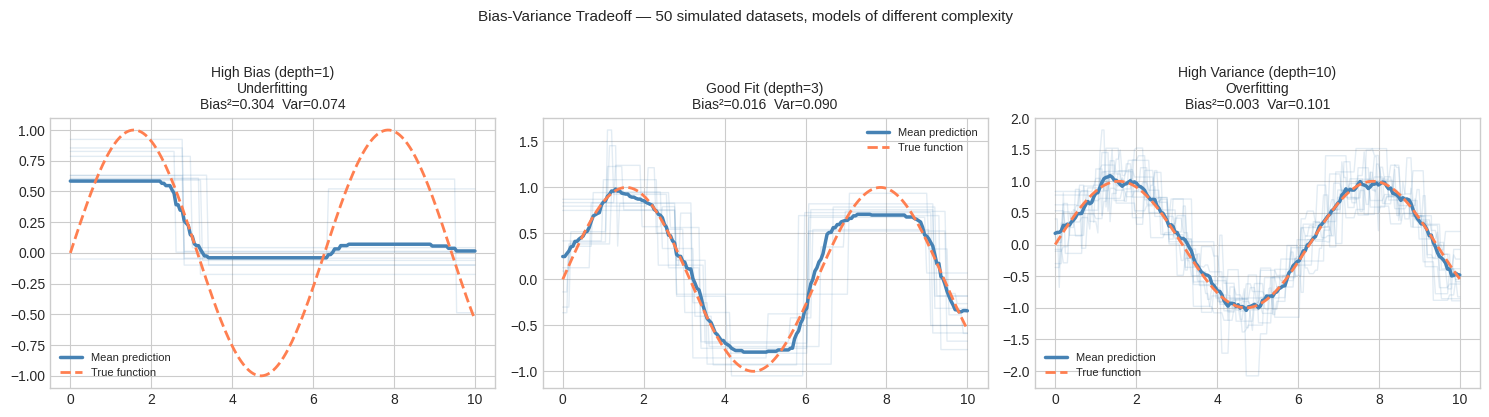

In [2]:
# ── Bias-Variance Tradeoff visualization ─────────────────────────────────
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# True function: sin curve
X_bv = np.linspace(0, 10, 200).reshape(-1, 1)
y_true = np.sin(X_bv.ravel())

# Simulate many datasets and fit models of different complexity
n_simulations = 50
depths         = [1, 3, 10]
all_preds      = {d: [] for d in depths}

for _ in range(n_simulations):
    X_sim = np.sort(rng.uniform(0, 10, 50)).reshape(-1, 1)
    y_sim = np.sin(X_sim.ravel()) + rng.normal(0, 0.3, 50)
    for d in depths:
        tree = DecisionTreeRegressor(max_depth=d)
        tree.fit(X_sim, y_sim)
        all_preds[d].append(tree.predict(X_bv))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['High Bias (depth=1)\nUnderfitting', 'Good Fit (depth=3)', 'High Variance (depth=10)\nOverfitting']

for ax, d, label in zip(axes, depths, labels):
    preds = np.array(all_preds[d])
    mean_pred = preds.mean(axis=0)
    for pred in preds[:10]:
        ax.plot(X_bv, pred, color='steelblue', alpha=0.15, linewidth=1)
    ax.plot(X_bv, mean_pred, color='steelblue', linewidth=2.5, label='Mean prediction')
    ax.plot(X_bv, y_true,   color='coral',     linewidth=2,   linestyle='--', label='True function')
    bias2  = np.mean((mean_pred - y_true)**2)
    var_   = np.mean(preds.var(axis=0))
    ax.set_title(f'{label}\nBias²={bias2:.3f}  Var={var_:.3f}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Bias-Variance Tradeoff — 50 simulated datasets, models of different complexity',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


In [3]:
# ── Classification metrics from scratch ──────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

data  = load_breast_cancer()
X, y  = data.data, data.target
X_tr, X_te, y_tr, y_te = __import__('sklearn.model_selection', fromlist=['train_test_split']).train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipe = Pipeline([('sc', StandardScaler()),
                  ('lr', LogisticRegression(max_iter=1000, random_state=42))])
pipe.fit(X_tr, y_tr)
y_pred      = pipe.predict(X_te)
y_pred_prob = pipe.predict_proba(X_te)[:,1]

# Manual computation of all metrics
TP = ((y_pred == 1) & (y_te == 1)).sum()
TN = ((y_pred == 0) & (y_te == 0)).sum()
FP = ((y_pred == 1) & (y_te == 0)).sum()
FN = ((y_pred == 0) & (y_te == 1)).sum()

accuracy  = (TP + TN) / len(y_te)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * precision * recall / (precision + recall)
specificity = TN / (TN + FP)

print('Confusion Matrix:')
print(f'  TP={TP}  FP={FP}')
print(f'  FN={FN}  TN={TN}')
print(f'\nMetrics (manual):')
print(f'  Accuracy:    {accuracy:.4f}')
print(f'  Precision:   {precision:.4f}')
print(f'  Recall:      {recall:.4f}')
print(f'  F1 Score:    {f1:.4f}')
print(f'  Specificity: {specificity:.4f}')


Confusion Matrix:
  TP=71  FP=1
  FN=1  TN=41

Metrics (manual):
  Accuracy:    0.9825
  Precision:   0.9861
  Recall:      0.9861
  F1 Score:    0.9861
  Specificity: 0.9762


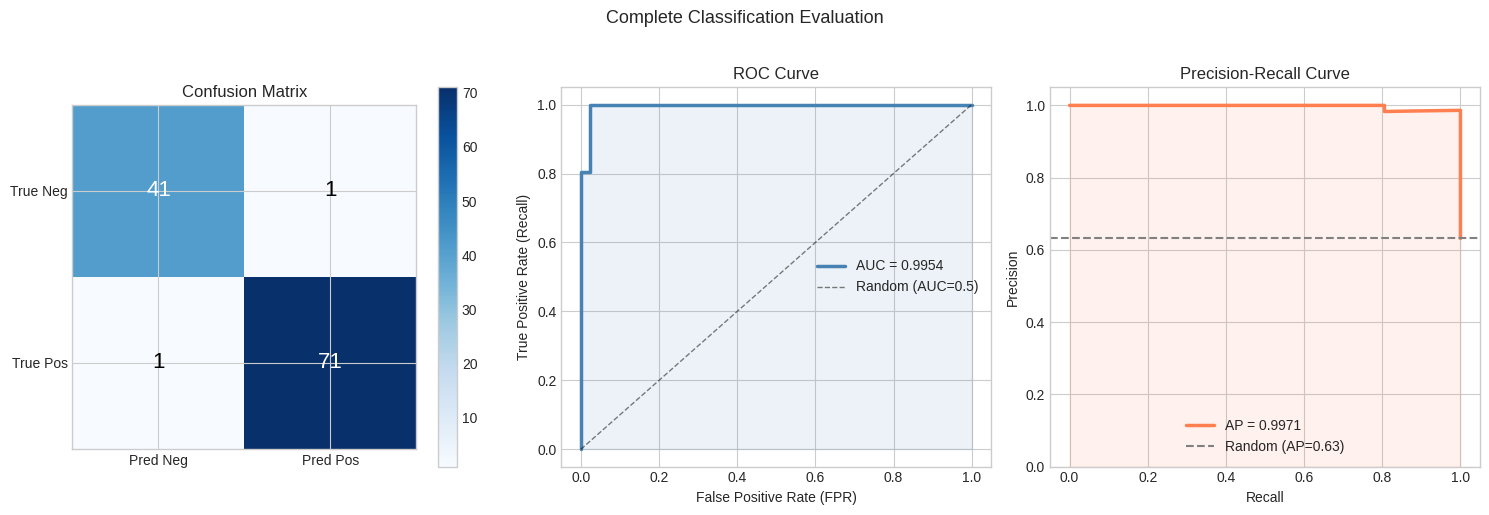

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [4]:
# Comprehensive evaluation plot
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              classification_report)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Neg','Pred Pos'])
axes[0].set_yticklabels(['True Neg','True Pos'])
axes[0].set_title('Confusion Matrix', fontsize=12)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, color='white' if cm[i,j]>cm.max()//2 else 'black')

# ── ROC Curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_te, y_pred_prob)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(fontsize=10)

# ── Precision-Recall Curve ────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_te, y_pred_prob)
ap           = average_precision_score(y_te, y_pred_prob)
baseline     = y_te.mean()
axes[2].plot(rec, prec, color='coral', linewidth=2.5, label=f'AP = {ap:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
                label=f'Random (AP={baseline:.2f})')
axes[2].fill_between(rec, prec, alpha=0.1, color='coral')
axes[2].set_title('Precision-Recall Curve', fontsize=12)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=10); axes[2].set_ylim(0, 1.05)

plt.suptitle('Complete Classification Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=data.target_names))


Regression Metrics — California Housing:
  MAE:         0.3275  (mean absolute error in $100k)
  MSE:         0.2554
  RMSE:        0.5053  (same unit as target)
  R²:          0.8051  (80.5% variance explained)
  Adj R²:      0.8047
  MAPE:        18.92%


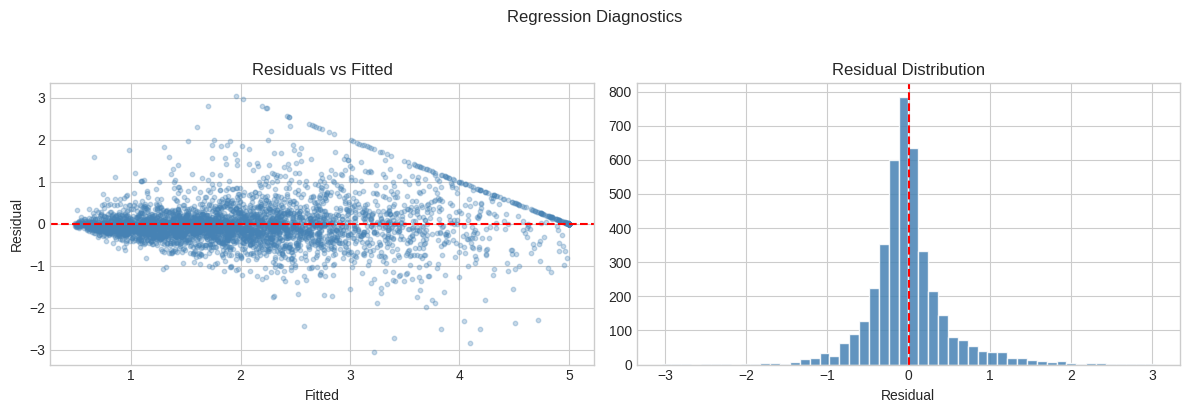

In [5]:
# ── Regression Metrics ────────────────────────────────────────────────────
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
X_tr_h, X_te_h, y_tr_h, y_te_h = __import__('sklearn.model_selection',
    fromlist=['train_test_split']).train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_tr_h, y_tr_h)
y_pred_h = rf_reg.predict(X_te_h)

mae  = mean_absolute_error(y_te_h, y_pred_h)
mse  = mean_squared_error(y_te_h, y_pred_h)
rmse = np.sqrt(mse)
r2   = r2_score(y_te_h, y_pred_h)

# Adjusted R2
m, p = X_te_h.shape
r2_adj = 1 - (1 - r2) * (m - 1) / (m - p - 1)

# MAPE (only for non-zero targets)
mape = np.mean(np.abs((y_te_h - y_pred_h) / y_te_h)) * 100

print('Regression Metrics — California Housing:')
print(f'  MAE:         {mae:.4f}  (mean absolute error in $100k)')
print(f'  MSE:         {mse:.4f}')
print(f'  RMSE:        {rmse:.4f}  (same unit as target)')
print(f'  R²:          {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  Adj R²:      {r2_adj:.4f}')
print(f'  MAPE:        {mape:.2f}%')

# Residual plot
residuals = y_te_h - y_pred_h
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_h, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Fitted'); axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Distribution'); axes[1].set_xlabel('Residual')

plt.suptitle('Regression Diagnostics', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# ── Cross-Validation strategies ───────────────────────────────────────────
from sklearn.model_selection import (
    KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit,
    cross_val_score, cross_validate
)
from sklearn.datasets import load_iris

iris = load_iris()
X_cv, y_cv = iris.data, iris.target

lr_cv = Pipeline([('sc', StandardScaler()),
                   ('lr', LogisticRegression(max_iter=1000, random_state=42))])

strategies = [
    ('KFold(5)',           KFold(n_splits=5, shuffle=True, random_state=42)),
    ('StratifiedKFold(5)', StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
    ('KFold(10)',          KFold(n_splits=10, shuffle=True, random_state=42)),
]

print(f'{'CV Strategy':<22}  {'Mean Acc':>10}  {'Std':>8}  {'n_fits':>8}')
for name, cv in strategies:
    scores = cross_val_score(lr_cv, X_cv, y_cv, cv=cv, scoring='accuracy')
    print(f'{name:<22}  {scores.mean():10.4f}  {scores.std():8.4f}  {len(scores):8d}')


CV Strategy               Mean Acc       Std    n_fits
KFold(5)                    0.9533    0.0340         5
StratifiedKFold(5)          0.9533    0.0452         5
KFold(10)                   0.9533    0.0670        10


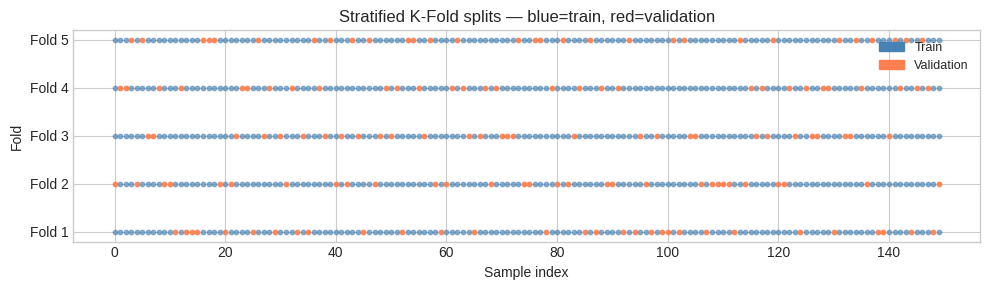

In [7]:
# Visualize K-Fold splits
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fig, ax = plt.subplots(figsize=(10, 3))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    ax.scatter(tr_idx,  [fold]*len(tr_idx),  c='steelblue', s=10, alpha=0.6)
    ax.scatter(val_idx, [fold]*len(val_idx), c='coral',     s=10, alpha=0.9)

ax.set_title('Stratified K-Fold splits — blue=train, red=validation')
ax.set_xlabel('Sample index'); ax.set_ylabel('Fold')
ax.set_yticks(range(5)); ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Train'),
                   Patch(color='coral',     label='Validation')], fontsize=9)
plt.tight_layout()
plt.show()


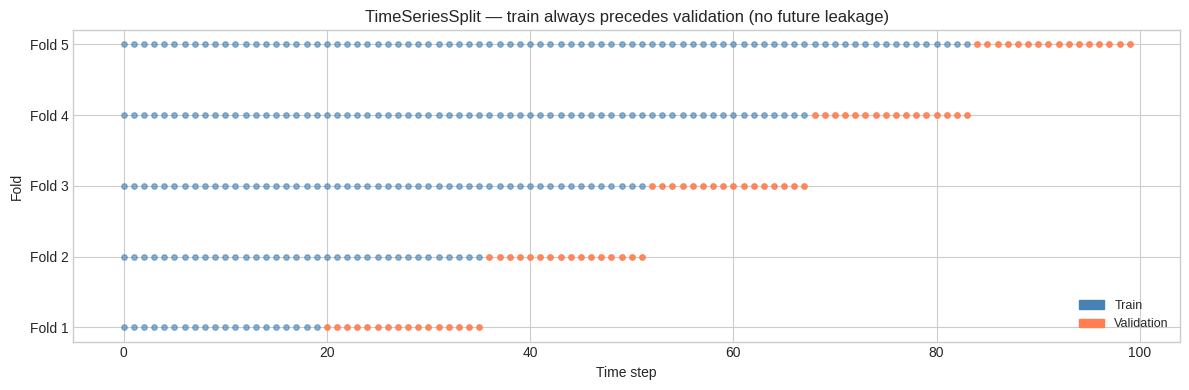

In [8]:
# Time Series CV — never use standard K-Fold for time series!
tscv = TimeSeriesSplit(n_splits=5)
X_ts = np.arange(100).reshape(-1, 1)
y_ts = np.sin(X_ts.ravel() * 0.1) + rng.normal(0, 0.1, 100)

fig, ax = plt.subplots(figsize=(12, 4))

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_ts)):
    ax.scatter(tr_idx,  [fold]*len(tr_idx),  c='steelblue', s=15, alpha=0.6)
    ax.scatter(val_idx, [fold]*len(val_idx), c='coral',     s=15, alpha=0.9)

ax.set_title('TimeSeriesSplit — train always precedes validation (no future leakage)')
ax.set_xlabel('Time step'); ax.set_ylabel('Fold')
ax.set_yticks(range(5)); ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.legend(handles=[Patch(color='steelblue', label='Train'),
                   Patch(color='coral',     label='Validation')], fontsize=9)
plt.tight_layout()
plt.show()


In [9]:
# ── GridSearchCV vs RandomizedSearchCV ───────────────────────────────────
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform
import time

X_ht, y_ht = load_breast_cancer(return_X_y=True)
X_tr_ht, X_te_ht, y_tr_ht, y_te_ht = __import__('sklearn.model_selection',
    fromlist=['train_test_split']).train_test_split(
    X_ht, y_ht, test_size=0.2, random_state=42, stratify=y_ht)

# GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, None],
    'max_features': ['sqrt', 'log2'],
}
t0   = time.time()
grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_tr_ht, y_tr_ht)
t_grid = time.time() - t0

# RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth':    [3, 5, 10, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_leaf': randint(1, 10),
}
t0     = time.time()
rand   = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                             param_dist, n_iter=18, cv=5,
                             scoring='accuracy', random_state=42, n_jobs=-1)
rand.fit(X_tr_ht, y_tr_ht)
t_rand = time.time() - t0

print(f'GridSearchCV ({len(param_grid["n_estimators"])*len(param_grid["max_depth"])*len(param_grid["max_features"])*5} fits):')
print(f'  Best CV acc:  {grid.best_score_:.4f}')
print(f'  Test acc:     {grid.best_estimator_.score(X_te_ht, y_te_ht):.4f}')
print(f'  Best params:  {grid.best_params_}')
print(f'  Time:         {t_grid:.2f}s')

print(f'\nRandomizedSearchCV (18*5=90 fits):')
print(f'  Best CV acc:  {rand.best_score_:.4f}')
print(f'  Test acc:     {rand.best_estimator_.score(X_te_ht, y_te_ht):.4f}')
print(f'  Best params:  {rand.best_params_}')
print(f'  Time:         {t_rand:.2f}s')


GridSearchCV (90 fits):
  Best CV acc:  0.9604
  Test acc:     0.9561
  Best params:  {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
  Time:         27.25s

RandomizedSearchCV (18*5=90 fits):
  Best CV acc:  0.9604
  Test acc:     0.9561
  Best params:  {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 7, 'n_estimators': 477}
  Time:         71.68s


In [10]:
# ── Nested CV — honest evaluation ────────────────────────────────────────
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

# Standard (optimistic) evaluation — grid search then test on same test set
grid_std = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [50, 100], 'max_depth': [3, 5, None]},
    cv=5, scoring='accuracy'
)
grid_std.fit(X_tr_ht, y_tr_ht)
std_test_acc = grid_std.best_estimator_.score(X_te_ht, y_te_ht)

# Nested CV — unbiased evaluation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

nested_scores = cross_val_score(
    GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators': [50, 100], 'max_depth': [3, 5, None]},
        cv=inner_cv, scoring='accuracy'
    ),
    X_ht, y_ht, cv=outer_cv, scoring='accuracy', n_jobs=-1
)

print('Nested CV vs Standard evaluation:')
print(f'  Standard test accuracy:          {std_test_acc:.4f}  (can be optimistic)')
print(f'  Nested CV mean accuracy:         {nested_scores.mean():.4f} ± {nested_scores.std():.4f}')
print(f'  Difference (optimism bias):      {std_test_acc - nested_scores.mean():.4f}')
print()
print('Nested CV gives an unbiased estimate of how well the model')
print('selection procedure generalizes to truly unseen data.')


Nested CV vs Standard evaluation:
  Standard test accuracy:          0.9561  (can be optimistic)
  Nested CV mean accuracy:         0.9543 ± 0.0128
  Difference (optimism bias):      0.0018

Nested CV gives an unbiased estimate of how well the model
selection procedure generalizes to truly unseen data.


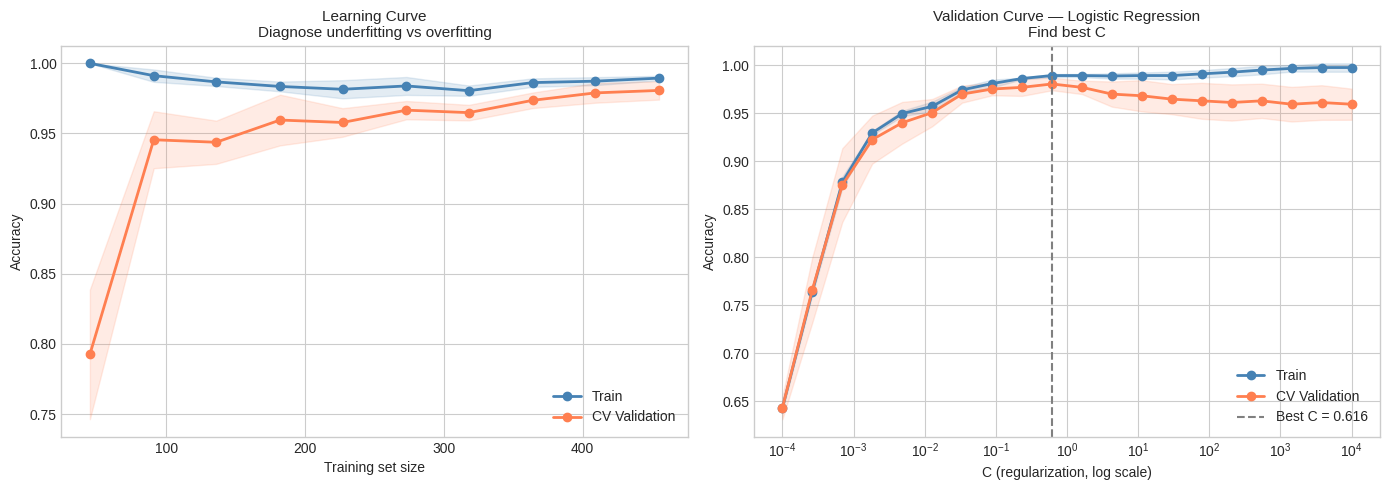

Learning curve interpretation:
  Train >> Val:   high variance (overfitting) — more data or regularization
  Both low:       high bias (underfitting)    — more complex model
  Both high:      good fit


In [11]:
# ── Learning and Validation Curves ───────────────────────────────────────
from sklearn.model_selection import learning_curve, validation_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Learning Curve — diagnose bias vs variance ────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    Pipeline([('sc', StandardScaler()),
              ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    X_ht, y_ht,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

axes[0].plot(train_sizes, tr_mean, 'o-', color='steelblue', linewidth=2, label='Train')
axes[0].fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='steelblue')
axes[0].plot(train_sizes, vl_mean, 'o-', color='coral', linewidth=2, label='CV Validation')
axes[0].fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.15, color='coral')
axes[0].set_title('Learning Curve\nDiagnose underfitting vs overfitting', fontsize=11)
axes[0].set_xlabel('Training set size'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

# ── Validation Curve — find best hyperparameter value ─────────────────────
C_range = np.logspace(-4, 4, 20)
tr_sc, val_sc = validation_curve(
    Pipeline([('sc', StandardScaler()),
              ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    X_ht, y_ht,
    param_name='lr__C', param_range=C_range,
    cv=5, scoring='accuracy', n_jobs=-1
)

tr_m, tr_s = tr_sc.mean(axis=1), tr_sc.std(axis=1)
vl_m, vl_s = val_sc.mean(axis=1), val_sc.std(axis=1)

axes[1].semilogx(C_range, tr_m, 'o-', color='steelblue', linewidth=2, label='Train')
axes[1].fill_between(C_range, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='steelblue')
axes[1].semilogx(C_range, vl_m, 'o-', color='coral', linewidth=2, label='CV Validation')
axes[1].fill_between(C_range, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color='coral')

best_C = C_range[np.argmax(vl_m)]
axes[1].axvline(best_C, color='gray', linestyle='--', linewidth=1.5,
                label=f'Best C = {best_C:.3f}')
axes[1].set_title('Validation Curve — Logistic Regression\nFind best C', fontsize=11)
axes[1].set_xlabel('C (regularization, log scale)'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Learning curve interpretation:')
print('  Train >> Val:   high variance (overfitting) — more data or regularization')
print('  Both low:       high bias (underfitting)    — more complex model')
print('  Both high:      good fit')


## 8. Common Mistakes

In [12]:
# MISTAKE 1: Using accuracy on imbalanced data
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

rng2 = np.random.default_rng(0)
n    = 1000
# 5% positive class
y_imb  = np.zeros(n, dtype=int)
y_imb[:50] = 1

y_dummy_all0 = np.zeros(n, dtype=int)   # always predict negative
y_dummy_rand = rng2.integers(0, 2, n)   # random predictions

print('Imbalanced dataset (5% positive):')
print(f'  Always predict 0  — Accuracy: {accuracy_score(y_imb, y_dummy_all0):.4f}  F1: {f1_score(y_imb, y_dummy_all0, zero_division=0):.4f}')
print(f'  Random predictions — Accuracy: {accuracy_score(y_imb, y_dummy_rand):.4f}  F1: {f1_score(y_imb, y_dummy_rand, zero_division=0):.4f}')
print()
print('95% accuracy looks great — but the model catches ZERO positive cases!')
print('Always use F1, AUC-ROC, or PR-AUC on imbalanced data.')


Imbalanced dataset (5% positive):
  Always predict 0  — Accuracy: 0.9500  F1: 0.0000
  Random predictions — Accuracy: 0.4670  F1: 0.0920

95% accuracy looks great — but the model catches ZERO positive cases!
Always use F1, AUC-ROC, or PR-AUC on imbalanced data.


In [13]:
# MISTAKE 2: Using test set for hyperparameter tuning (optimism bias)
# Every time you look at test performance and adjust based on it,
# you are effectively training on the test set.

print('The Three-Split Rule:')
print('  Training set   -> fit model parameters (weights)')
print('  Validation set -> tune hyperparameters (C, K, depth)')
print('  Test set       -> final evaluation ONCE, NEVER used for decisions')

print('\nIf you only have limited data, use:')
print('  Cross-validation     for hyperparameter tuning')
print('  Nested CV            for unbiased final evaluation')
print('  Hold out test set    report results on it ONCE at the very end')


The Three-Split Rule:
  Training set   -> fit model parameters (weights)
  Validation set -> tune hyperparameters (C, K, depth)
  Test set       -> final evaluation ONCE, NEVER used for decisions

If you only have limited data, use:
  Cross-validation     for hyperparameter tuning
  Nested CV            for unbiased final evaluation
  Hold out test set    report results on it ONCE at the very end


In [14]:
# MISTAKE 3: Not using stratified splits for classification
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd

# Imbalanced data: 10% class 1
X_strat = rng2.normal(0, 1, (200, 2))
y_strat = (rng2.random(200) < 0.1).astype(int)

print(f'Full dataset class distribution: {np.bincount(y_strat)}')

# Without stratification
for trial in range(5):
    _, _, y_tr_ns, y_te_ns = train_test_split(X_strat, y_strat, test_size=0.2)
    print(f'  Random split trial {trial+1}: '
          f'train pos={y_tr_ns.mean():.3f}, test pos={y_te_ns.mean():.3f}')

print()
# With stratification
for trial in range(5):
    _, _, y_tr_s, y_te_s = train_test_split(X_strat, y_strat,
                                             test_size=0.2, stratify=y_strat)
    print(f'  Stratified split trial {trial+1}: '
          f'train pos={y_tr_s.mean():.3f}, test pos={y_te_s.mean():.3f}')

print('\nStratified splits preserve class proportions in every fold.')


Full dataset class distribution: [176  24]
  Random split trial 1: train pos=0.125, test pos=0.100
  Random split trial 2: train pos=0.106, test pos=0.175
  Random split trial 3: train pos=0.113, test pos=0.150
  Random split trial 4: train pos=0.106, test pos=0.175
  Random split trial 5: train pos=0.106, test pos=0.175

  Stratified split trial 1: train pos=0.119, test pos=0.125
  Stratified split trial 2: train pos=0.119, test pos=0.125
  Stratified split trial 3: train pos=0.119, test pos=0.125
  Stratified split trial 4: train pos=0.119, test pos=0.125
  Stratified split trial 5: train pos=0.119, test pos=0.125

Stratified splits preserve class proportions in every fold.


## 9. Exercises

**Exercise 1:** Implement precision, recall, F1, and ROC-AUC from scratch (without sklearn metrics). Verify all values match sklearn on the breast cancer dataset.


In [15]:
# Your code here


In [16]:
# Solution
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def compute_metrics(y_true, y_pred, y_prob):
    TP = ((y_pred==1)&(y_true==1)).sum()
    TN = ((y_pred==0)&(y_true==0)).sum()
    FP = ((y_pred==1)&(y_true==0)).sum()
    FN = ((y_pred==0)&(y_true==1)).sum()

    precision = TP/(TP+FP) if (TP+FP)>0 else 0
    recall    = TP/(TP+FN) if (TP+FN)>0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

    # AUC — trapezoidal rule over all thresholds
    thresholds = np.sort(np.unique(y_prob))[::-1]
    fprs, tprs = [0], [0]
    for t in thresholds:
        p   = (y_prob >= t).astype(int)
        tp_ = ((p==1)&(y_true==1)).sum()
        fp_ = ((p==1)&(y_true==0)).sum()
        fprs.append(fp_/((y_true==0).sum()))
        tprs.append(tp_/((y_true==1).sum()))
    fprs, tprs = np.array(fprs+[1]), np.array(tprs+[1])
    auc_scratch = np.trapz(tprs, fprs)

    return precision, recall, f1, auc_scratch

p_s, r_s, f1_s, auc_s = compute_metrics(y_te, y_pred, y_pred_prob)
print(f'{'Metric':<12}  {'Scratch':>10}  {'Sklearn':>10}  {'Match':>8}')
for name, s, sk in [
    ('Precision', p_s,   precision_score(y_te, y_pred)),
    ('Recall',    r_s,   recall_score(y_te, y_pred)),
    ('F1',        f1_s,  f1_score(y_te, y_pred)),
    ('AUC-ROC',   auc_s, roc_auc_score(y_te, y_pred_prob)),
]:
    print(f'{name:<12}  {s:10.6f}  {sk:10.6f}  {str(np.isclose(s,sk,atol=1e-3)):>8}')


Metric           Scratch     Sklearn     Match
Precision       0.986111    0.986111      True
Recall          0.986111    0.986111      True
F1              0.986111    0.986111      True
AUC-ROC         0.995370    0.995370      True


**Exercise 2:** Compare K-Fold (K=5, 10) and Leave-One-Out CV on the Iris dataset using Logistic Regression. Report mean accuracy and std for each. Which has the lowest bias? Which has the lowest variance? Which would you use for a dataset of 1000 samples?


In [17]:
# Your code here


In [18]:
# Solution
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score

iris2 = load_iris()
X_loo, y_loo = iris2.data, iris2.target
lr_loo = Pipeline([('sc', StandardScaler()),
                    ('lr', LogisticRegression(max_iter=1000, random_state=42))])

print(f'{'CV Strategy':<20}  {'Mean Acc':>10}  {'Std':>8}  {'n_fits':>8}')
for name, cv in [
    ('KFold(5)',   KFold(n_splits=5,  shuffle=True, random_state=42)),
    ('KFold(10)',  KFold(n_splits=10, shuffle=True, random_state=42)),
    ('LOO-CV',     LeaveOneOut()),
]:
    s = cross_val_score(lr_loo, X_loo, y_loo, cv=cv, scoring='accuracy')
    print(f'{name:<20}  {s.mean():10.4f}  {s.std():8.4f}  {len(s):8d}')

print()
print('LOO-CV: lowest bias (uses most data per fold), but highest variance and slowest.')
print('KFold(5): best tradeoff for large datasets — use this by default.')
print('KFold(10): slightly less bias than KFold(5), 2x slower.')


CV Strategy             Mean Acc       Std    n_fits
KFold(5)                  0.9533    0.0340         5
KFold(10)                 0.9533    0.0670        10
LOO-CV                    0.9533    0.2109       150

LOO-CV: lowest bias (uses most data per fold), but highest variance and slowest.
KFold(5): best tradeoff for large datasets — use this by default.
KFold(10): slightly less bias than KFold(5), 2x slower.


**Exercise 3:** On the breast cancer dataset, compare:
1. A RandomForest trained on raw features
2. The same model trained after feature selection (top 10 by F-test)

Use nested CV (outer=5-fold, inner=3-fold GridSearch over `n_estimators` and `max_depth`) to get an honest performance estimate for each. Report mean accuracy ± std.


In [19]:
# Your code here


In [20]:
# Solution
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

X_ex3, y_ex3 = load_breast_cancer(return_X_y=True)

outer = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
inner = StratifiedKFold(n_splits=3,  shuffle=True, random_state=42)

param_g = {'clf__n_estimators': [50, 100], 'clf__max_depth': [3, 5, None]}

pipe_raw = Pipeline([('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])
pipe_sel = Pipeline([
    ('sel', SelectKBest(f_classif, k=10)),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])
param_g_sel = {'clf__n_estimators': [50,100], 'clf__max_depth': [3,5,None]}

print(f'{'Pipeline':<28}  {'Nested CV Acc':>14}  {'Std':>8}')
for name, pipe, pg in [
    ('Raw features (30)',   pipe_raw, param_g),
    ('F-test selection (10)', pipe_sel, param_g_sel),
]:
    gs = GridSearchCV(pipe, pg, cv=inner, scoring='accuracy', n_jobs=-1)
    s  = cross_val_score(gs, X_ex3, y_ex3, cv=outer, scoring='accuracy', n_jobs=-1)
    print(f'{name:<28}  {s.mean():14.4f}  {s.std():8.4f}')

print('\nNested CV gives an honest comparison — not inflated by test set peeking.')


Pipeline                       Nested CV Acc       Std
Raw features (30)                     0.9543    0.0128
F-test selection (10)                 0.9420    0.0196

Nested CV gives an honest comparison — not inflated by test set peeking.


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
